# LArTPC event display

Projected + 3D views of ionization track in the TPC, built using ADC waveforms from **GramsElecSim**:

- **xz view** — anode *x* channel number vs drift *z*
- **yz view** — anode *y* channel number vs drift *z*
- **3D view** — (x channel, y channel, drift z) voxels

The colour axis is always **waveform amplitude (ADC counts)**. Every readout
pixel carries an `(x_index, y_index)` channel and a digitized drift-time
waveform; the drift axis is reconstructed from the ADC sample number
(0.5 us/sample, `v_drift = 0.16 cm/us`).

Every event is drawn on the same fixed grid: the **full 90 x channels x 90 y
channels** anode and the **full readout window**.

**To look at a different event, just change `PARTICLE` / `EVENT_INDEX` in the
config cell and re-run.** The heavy lifting lives in
[`scripts/event_display.py`](../../scripts/event_display.py).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/nevis/wanaka/share/standon/GRAMS/GramsOccupancy')
from scripts.event_display import (load_event_images, load_event_points,
                                   list_busy_events, ADC_SATURATION)
from scripts.config import PARTICLE_DICT

plt.style.use('~/latex-cm.mplstyle')

particle_names = {k: v[0] for k, v in PARTICLE_DICT.items()}

## Configuration knobs

`PARTICLE` is any key of `PARTICLE_DICT` (`'photon'`, `'muplus'`, `'mumins'`,
`'proton'`, `'electr'`, `'positr'`, `'he---4'`, `'neutro'`). `EVENT_INDEX` is
the 0-based entry in that particle's `ElecSim` tree.

In [7]:
PARTICLE = 'he---4'   # which particle run to look at
EVENT_INDEX = 296     # which event within that run

PROJECTION = 'max'    # 'max' -> peak ADC amplitude, 'sum' -> integrated ADC
Z_UNITS = 'us'        # drift-axis units: 'cm', 'us', or 'sample'

Need help finding an event with a visible track? `list_busy_events` ranks the
events with the most fired pixels (scans the first 300 events by default).

In [8]:
for idx, nch in list_busy_events(PARTICLE, n=10):
    print(f'event {idx:5d}: {nch:4d} fired pixels')

event   146: 4490 fired pixels
event    39: 3417 fired pixels
event   159: 3290 fired pixels
event   166: 2994 fired pixels
event     9: 2879 fired pixels
event   102: 2637 fired pixels
event   123: 2623 fired pixels
event     4: 2499 fired pixels
event   144: 2467 fired pixels
event   154: 2347 fired pixels


## 2D plotting helper

In [9]:
def display_event(particle, event_index, projection='max', z_units='cm',
                  cmap='viridis', log=False):
    img = load_event_images(particle, event_index, projection=projection,
                            z_units=z_units)

    pname = particle_names.get(particle, particle)
    if img['n_channels'] == 0:
        print(f'{pname} event {event_index} (ID {img["event_id"]}): no readout '
              'waveforms (no ionization reached the anode); showing empty detector.')

    cbar_label = ('peak ADC' if projection == 'max'
                  else 'projected ADC sum')
    # Shared colour scale across both views
    vmax = max(img['xz'].max(), img['yz'].max(), 1.0)
    if log:
        from matplotlib.colors import LogNorm
        norm = LogNorm(vmin=1, vmax=max(vmax, 2))
    else:
        from matplotlib.colors import Normalize
        norm = Normalize(vmin=0, vmax=vmax)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
    views = [('xz', img['x_edges'], 'x channel'),
             ('yz', img['y_edges'], 'y channel')]
    for ax, (key, edges, xlabel) in zip(axes, views):
        # image is [channel, z]; transpose so z is vertical, channel horizontal.
        mesh = ax.pcolormesh(edges, img['z_edges'], img[key].T,
                             cmap=cmap, norm=norm, shading='flat')
        ax.set_xlabel(xlabel)
        ax.set_title(f'{key} view')
        ax.set_xlim(edges[0], edges[-1])
    axes[0].set_ylabel(img['z_label'])
    axes[0].set_ylim(img['z_edges'][0], img['z_edges'][-1])
    axes[0].invert_yaxis()  # anode (z=0, small drift) at the top

    cbar = fig.colorbar(mesh, ax=axes, fraction=0.046, pad=0.02)
    cbar.set_label(cbar_label)

    fig.suptitle(f'{pname}, event {event_index}',
                 y=1.02)
    plt.show()
    return img

## 2D event display (xz / yz)

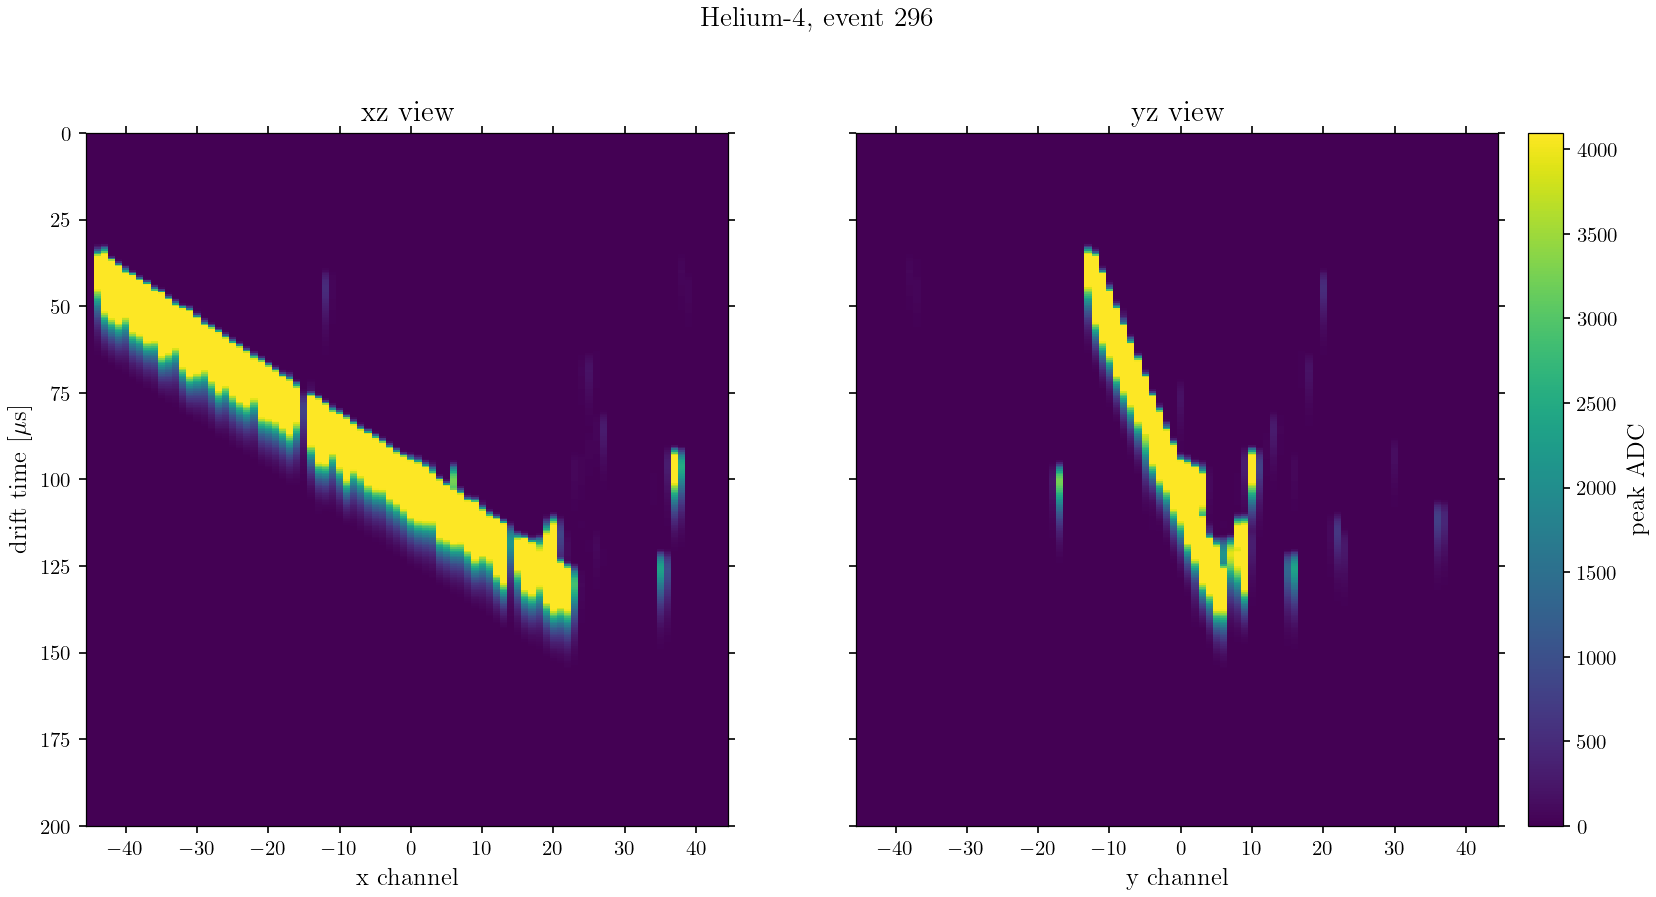

In [10]:
img = display_event(PARTICLE, EVENT_INDEX, projection=PROJECTION, z_units=Z_UNITS)

In [11]:
print(f'fired pixels:      {img["n_channels"]}')
print(f'readout window:    {img["nsamples"]} samples '
      f'(0.00-{img["z_edges"][-1]:.2f} {img["z_units"]})')
print(f'image size:        xz {img["xz"].shape}, yz {img["yz"].shape}')
print(f'peak ADC (xz/yz):  {img["xz"].max():.0f} / {img["yz"].max():.0f}'
      f'   (saturation = {ADC_SATURATION})')

fired pixels:      255
readout window:    400 samples (0.00-200.00 us)
image size:        xz (90, 400), yz (90, 400)
peak ADC (xz/yz):  4096 / 4096   (saturation = 4096)


## 3D event display

Each fired pixel's drift-time waveform is unpacked into voxels at
`(x channel, y channel, drift z)`, coloured by ADC. Only samples above
`REL_THRESHOLD x (event peak ADC)` are drawn, to keep the cloud readable. The
box spans the full detector grid, and the drift axis is inverted so the anode
(z = 0) is at the top. Drag to rotate (in an interactive backend), or set
`ELEV` / `AZIM` for a fixed viewpoint.

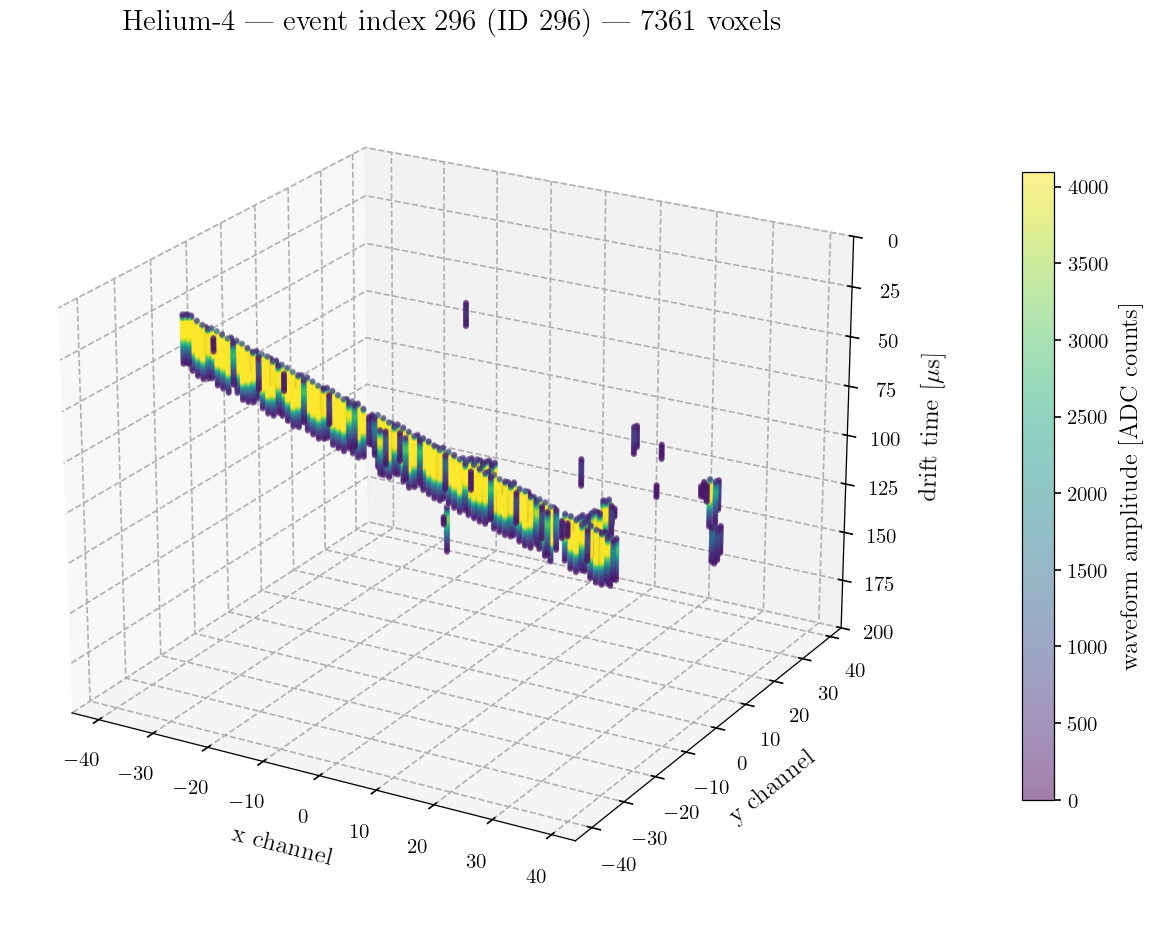

In [12]:
REL_THRESHOLD = 0.05   # keep ADC samples above this fraction of the event peak
ELEV, AZIM = 22, -60   # 3D viewpoint (degrees)

def display_event_3d(particle, event_index, z_units='cm', rel_threshold=0.05,
                     cmap='viridis', size=8, elev=22, azim=-60):
    """3D scatter of ADC voxels for one event, on the full detector grid."""
    pts = load_event_points(particle, event_index, z_units=z_units,
                            rel_threshold=rel_threshold)
    pname = particle_names.get(particle, particle)
    xmin, xmax, ymin, ymax, zfull = pts['grid']

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    if pts['n_points'] == 0:
        print(f'{pname} event {event_index} (ID {pts["event_id"]}): '
              'no voxels above threshold.')
    else:
        sc = ax.scatter(pts['x'], pts['y'], pts['z'], c=pts['adc'], cmap=cmap,
                        s=size, alpha=0.5, marker='o', linewidths=0,
                        vmin=0, vmax=max(pts['max_adc'], 1))
        cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.12)
        cbar.set_label('waveform amplitude [ADC counts]')

    ax.set_xlabel('x channel')
    ax.set_ylabel('y channel')
    ax.set_zlabel(pts['z_label'])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(0, zfull)
    ax.invert_zaxis()  # anode (z=0) at the top
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'{pname}  |  event index {event_index} (ID {pts["event_id"]})  |  '
                 f'{pts["n_points"]} voxels')
    plt.show()
    return pts

pts = display_event_3d(PARTICLE, EVENT_INDEX, z_units=Z_UNITS,
                       rel_threshold=REL_THRESHOLD, elev=ELEV, azim=AZIM)

## Truth-level interaction

The Geant4 truth for this event comes from the per-event DataFrame built by
[`scripts/extract_df.py`](../../scripts/extract_df.py) (cached parquet). The
**dominant daughter process** is the creation process of the primary's
earliest-in-time direct daughter that produced a LAr hit -- i.e. how the
primary first interacted in the detector. Truth rows are keyed by the event's
truth ID (`img['event_id']`), which matches `event_index` in the DataFrame.

In [13]:
from scripts.extract_df import extract_all_events

# Cached read of the per-event truth table (all particles).
events_df = extract_all_events()

# Human-readable Geant4 process names.
PROCESS_NAMES = {
    'compt': 'Compton scatter',
    'phot': 'photoelectric absorption',
    'conv': 'pair production (gamma -> e+e-)',
    'Rayl': 'Rayleigh scatter',
    'eBrem': 'bremsstrahlung',
    'eIoni': 'ionization (e+-)',
    'ionIoni': 'ionization (ion)',
    'hIoni': 'ionization (hadron)',
    'annihil': 'positron annihilation',
    'msc': 'multiple scattering',
    'hadElastic': 'hadronic elastic scatter',
    'neutronInelastic': 'neutron inelastic',
    'protonInelastic': 'proton inelastic',
    'Decay': 'decay',
    'muIoni': 'ionization (muon)',
}

def truth_summary(particle, event_id):
    """Print the truth-level dominant daughter process (+ context) for an event."""
    sub = events_df[(events_df['particle'] == particle) &
                    (events_df['event_index'] == event_id)]
    pname = particle_names.get(particle, particle)
    if sub.empty:
        print(f'No truth record for {pname} event_id {event_id}.')
        return None
    r = sub.iloc[0]
    dom = r['dominant_daughter_process']
    dom_name = PROCESS_NAMES.get(dom, dom if dom is not None else '(none)')
    procs = r['daughter_processes'] or '(none)'
    print(f'{pname}  |  event_id {event_id}')
    print(f'  dominant daughter process : {dom}  ({dom_name})')
    print(f'  all daughter processes    : {procs}')
    print(f'  primary energy            : {r["primary_energy"]:.3f} MeV')
    print(f'  containment               : {r["containment"]}')
    print(f'  LAr hits                  : {r["n_lar_hits"]}')
    return r

[CACHE] Loading from /nevis/wanaka/data/standon/GramsOccupancy/psf/pkl/events.parquet


In [14]:
_ = truth_summary(PARTICLE, img['event_id'])

Helium-4  |  event_id 296
  dominant daughter process : ionIoni  (ionization (ion))
  all daughter processes    : ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,ionIoni,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alphaInelastic,alph